In [ ]:
# ---------------------------------------------------------
# CELL 1: INITIALIZE AND LOAD
# ---------------------------------------------------------
%load_ext autoreload
%autoreload 2

import os
# REMOVE: os.environ["PYTENSOR_FLAGS"] = "cxx=" 
# ADD THIS INSTEAD: This helps PyTensor find your new Conda compiler
os.environ["PYTENSOR_FLAGS"] = "cxx_binary=" + os.path.join(os.environ["CONDA_PREFIX"], "bin", "clang++")

import pandas as pd
from db_tools import loaders

# Load the full dataset from your existing database
db_path = 'creditdatabase.db' # Ensure this matches your filename
df_raw = loaders.load_table_to_df(db_path, 'credit card transactions')

print(f"Initial Dataset Shape: {df_raw.shape}")
df_raw.head()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Loading full table 'credit card transactions'...
Initial Dataset Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
# ---------------------------------------------------------
# CELL 2: DEDUPLICATION
# ---------------------------------------------------------
# Find and remove exact duplicates
duplicates_count = df_raw.duplicated().sum()
print(f"Found {duplicates_count} duplicate rows. Removing them...")

df_clean = df_raw.drop_duplicates().reset_index(drop=True)
print(f"Cleaned Dataset Shape: {df_clean.shape}")

Found 1081 duplicate rows. Removing them...
Cleaned Dataset Shape: (283726, 31)


In [4]:
# ---------------------------------------------------------
# CELL 3: FEATURE SCALING
# ---------------------------------------------------------
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# We only scale the columns that aren't already scaled (Time and Amount)
# We keep the originals as 'Time_Scaled' and 'Amount_Scaled' for clarity
df_clean['Time'] = scaler.fit_transform(df_clean[['Time']])
df_clean['Amount'] = scaler.fit_transform(df_clean[['Amount']])

print("Time and Amount have been standardized (Mean ~ 0, Std ~ 1).")
df_clean[['Time', 'Amount']].describe().round(2)

Time and Amount have been standardized (Mean ~ 0, Std ~ 1).


,Time,Amount
count,283726.00,283726.00
mean,0.00,-0.00
std,1.00,1.00
min,-2.00,-0.35
25%,-0.86,-0.33
50%,-0.21,-0.27
75%,0.94,-0.04
max,1.64,102.25


In [5]:
# ---------------------------------------------------------
# CELL 4: IDENTIFYING THE TOP TATTLETALES (CORRELATION)
# ---------------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate how much each variable relates to 'Class'
correlations = df_clean.corr()['Class'].sort_values(ascending=False)

# Let's see the winners
print("--- Top 5 Positive Correlations (Fraud increases as these increase) ---")
print(correlations.head(6)) # .head(6) because 'Class' is correlated 1.0 with itself

print("\n--- Top 5 Negative Correlations (Fraud increases as these decrease) ---")
print(correlations.tail(5))

--- Top 5 Positive Correlations (Fraud increases as these increase) ---
Class    1.000000
V11      0.149067
V4       0.129326
V2       0.084624
V19      0.033631
V8       0.033068
Name: Class, dtype: float64

--- Top 5 Negative Correlations (Fraud increases as these decrease) ---
V16   -0.187186
V10   -0.206971
V12   -0.250711
V14   -0.293375
V17   -0.313498
Name: Class, dtype: float64


/var/folders/x5/1tq347gd0xx1mkphlj71gjk00000gn/T/ipykernel_34238/1879595120.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Class', y=feature, data=df_clean, ax=axes[i], palette='Set1')
/var/folders/x5/1tq347gd0xx1mkphlj71gjk00000gn/T/ipykernel_34238/1879595120.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Class', y=feature, data=df_clean, ax=axes[i], palette='Set1')
/var/folders/x5/1tq347gd0xx1mkphlj71gjk00000gn/T/ipykernel_34238/1879595120.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Class', y=feature, data=df_

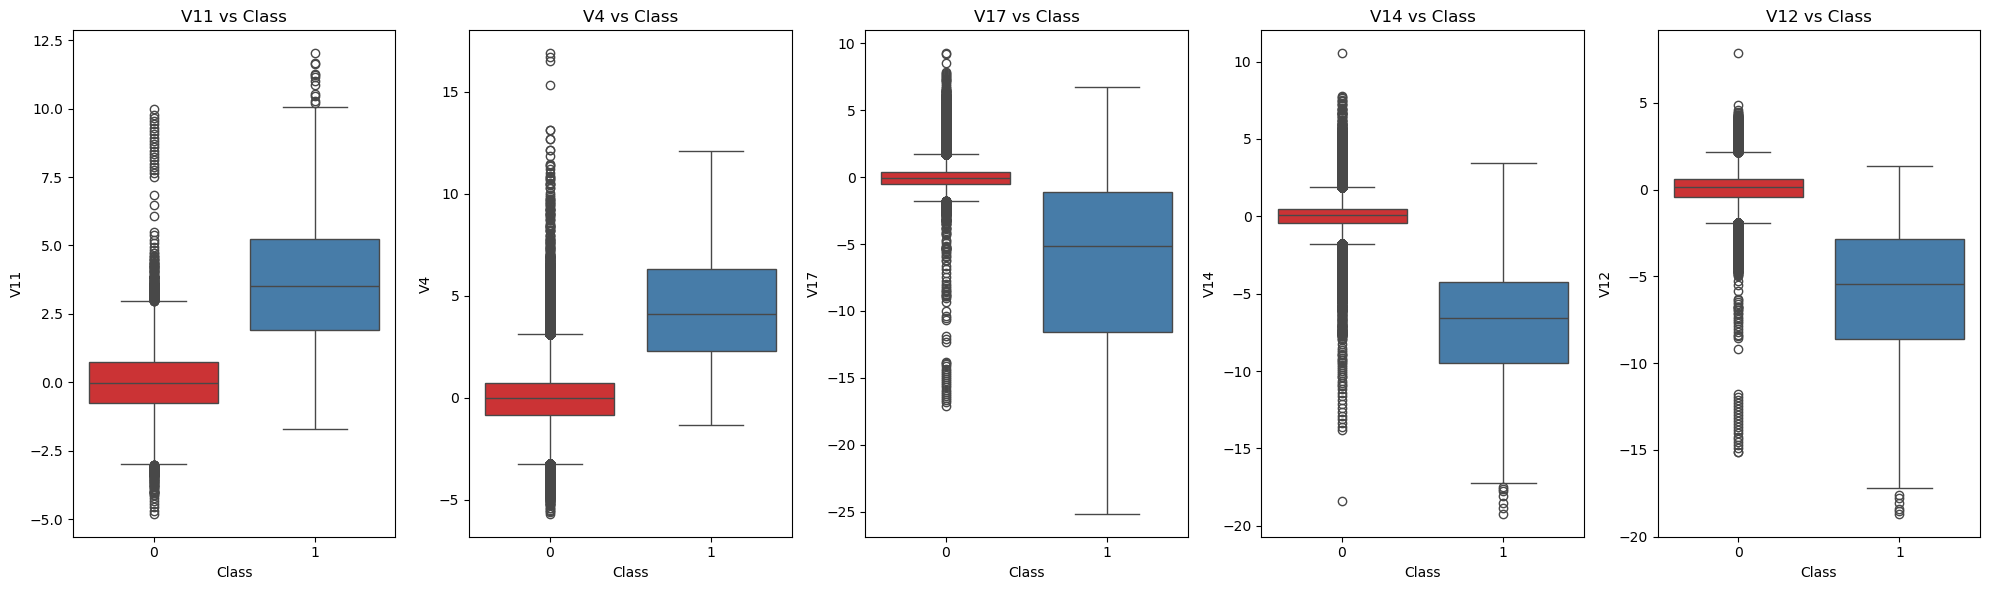

In [6]:
# ---------------------------------------------------------
# CELL 5: THE BOXPLOT LITMUS TEST
# ---------------------------------------------------------
# Let's pick the 5 strongest ones based on your results above
# Usually: V11, V4 (Positive) and V17, V14, V12 (Negative)
top_5_features = ['V11', 'V4', 'V17', 'V14', 'V12']

fig, axes = plt.subplots(1, 5, figsize=(20, 6))

for i, feature in enumerate(top_5_features):
    sns.boxplot(x='Class', y=feature, data=df_clean, ax=axes[i], palette='Set1')
    axes[i].set_title(f'{feature} vs Class')

plt.tight_layout()
plt.show()

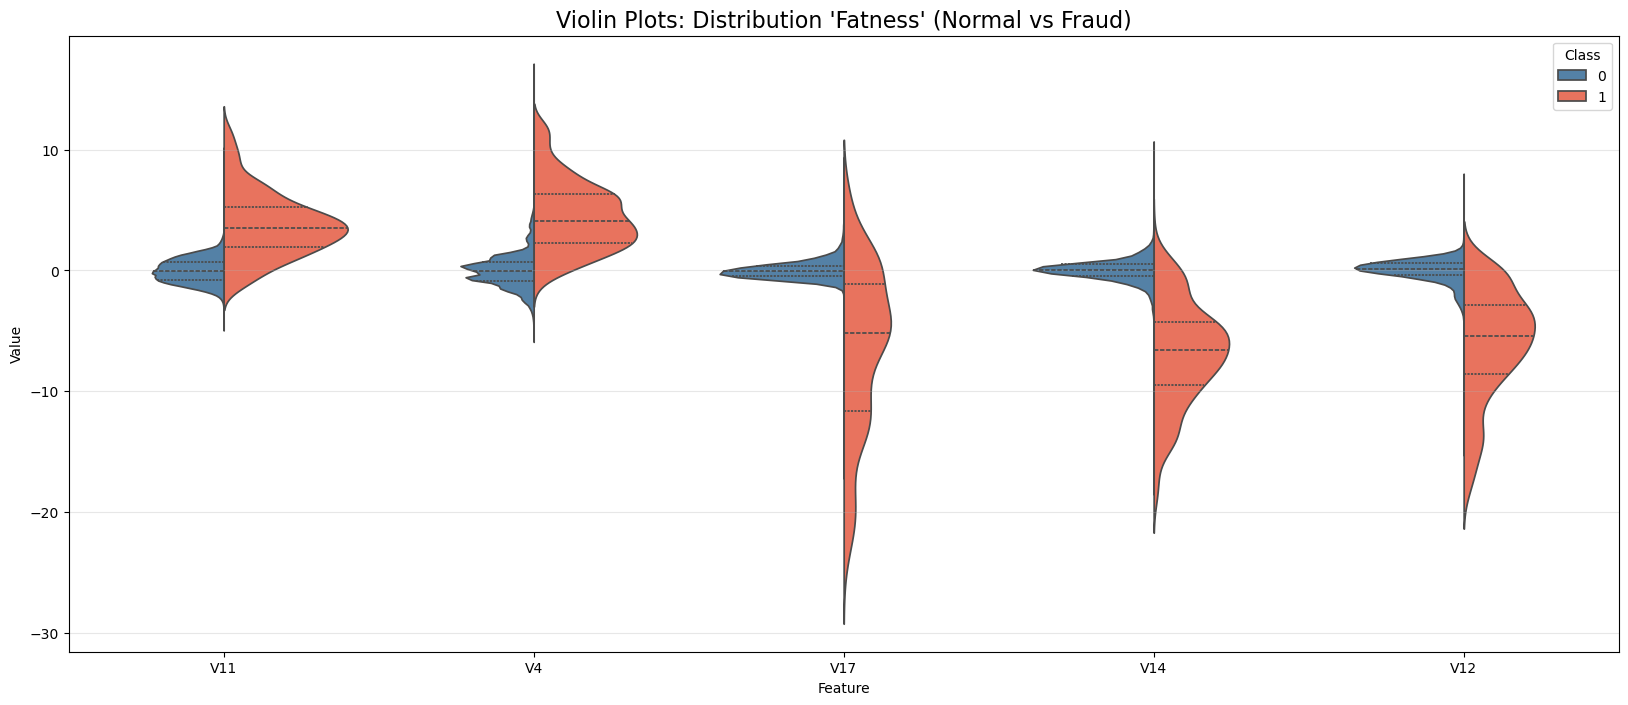

In [7]:
# ---------------------------------------------------------
# CELL 6: THE VIOLIN PLOT (DISTRIBUTION SHAPE)
# ---------------------------------------------------------
plt.figure(figsize=(20, 8))

# We'll melt the data so we can plot all 5 features side-by-side easily
df_melt = df_clean.melt(id_vars='Class', value_vars=top_5_features, 
                        var_name='Feature', value_name='Value')

sns.violinplot(x='Feature', y='Value', hue='Class', data=df_melt, 
               split=True, inner="quart", palette={0: "steelblue", 1: "tomato"})

plt.title("Violin Plots: Distribution 'Fatness' (Normal vs Fraud)", fontsize=16)
plt.grid(axis='y', alpha=0.3)
plt.show()

/var/folders/x5/1tq347gd0xx1mkphlj71gjk00000gn/T/ipykernel_34238/3884830555.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


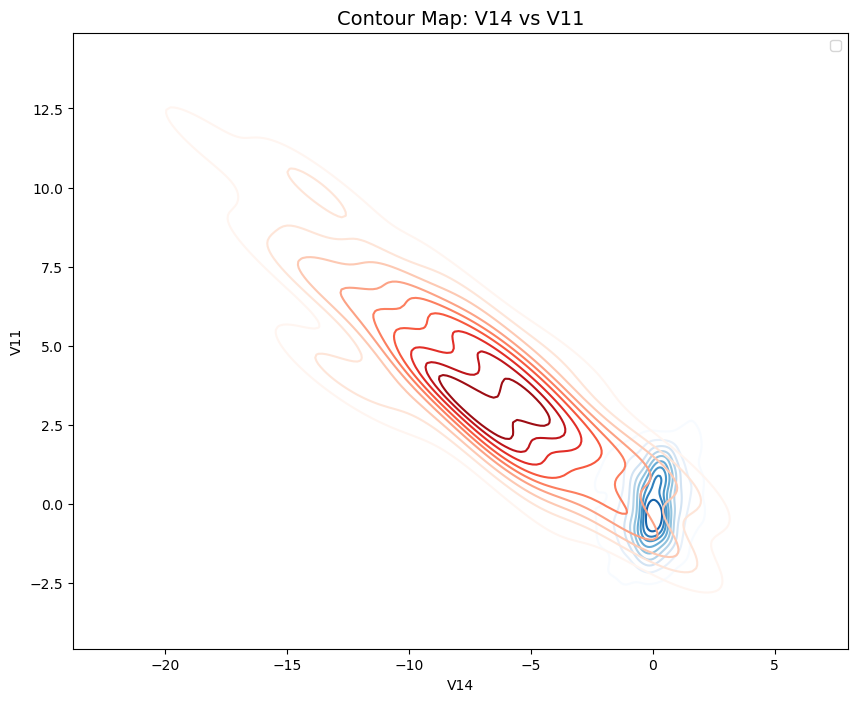

In [8]:
# ---------------------------------------------------------
# CELL 7: CONTOUR PLOTS (THE CAUSAL LANDSCAPE)
# ---------------------------------------------------------
# We'll pick V14 (strong negative) and V11 (strong positive)
feat_x = 'V14'
feat_y = 'V11'

plt.figure(figsize=(10, 8))

# Plot the 'Normal' density in Blue
sns.kdeplot(data=df_clean[df_clean['Class'] == 0].sample(2000), 
            x=feat_x, y=feat_y, cmap="Blues", fill=False, thresh=0.05, label="Normal")

# Plot the 'Fraud' density in Red
sns.kdeplot(data=df_clean[df_clean['Class'] == 1], 
            x=feat_x, y=feat_y, cmap="Reds", fill=False, thresh=0.05, label="Fraud")

plt.title(f"Contour Map: {feat_x} vs {feat_y}", fontsize=14)
plt.legend()
plt.show()

In [9]:
# ---------------------------------------------------------
# CELL 8: EXPANDED MULTICOLLINEARITY CHECK (VIF)
# ---------------------------------------------------------
from bayes_tools import dags

# Expanded list including your suggestions
my_features = ['V11', 'V4', 'V17', 'V14', 'V12', 'V10', 'V16']

# This function (from our module) calculates the VIF score.
# Remember: We want scores BELOW 5. 
vif_results = dags.assess_multicollinearity(df_clean, features=my_features)

Calculating Variance Inflation Factor (VIF) for 7 features...
V17        | VIF Score:   1.00 | PASS: Independent feature.
V14        | VIF Score:   1.00 | PASS: Independent feature.
V12        | VIF Score:   1.00 | PASS: Independent feature.
V16        | VIF Score:   1.00 | PASS: Independent feature.
V11        | VIF Score:   1.00 | PASS: Independent feature.
V10        | VIF Score:   1.00 | PASS: Independent feature.
V4         | VIF Score:   1.00 | PASS: Independent feature.


Generating pairwise distributions. Subsampling majority class to N=3000...


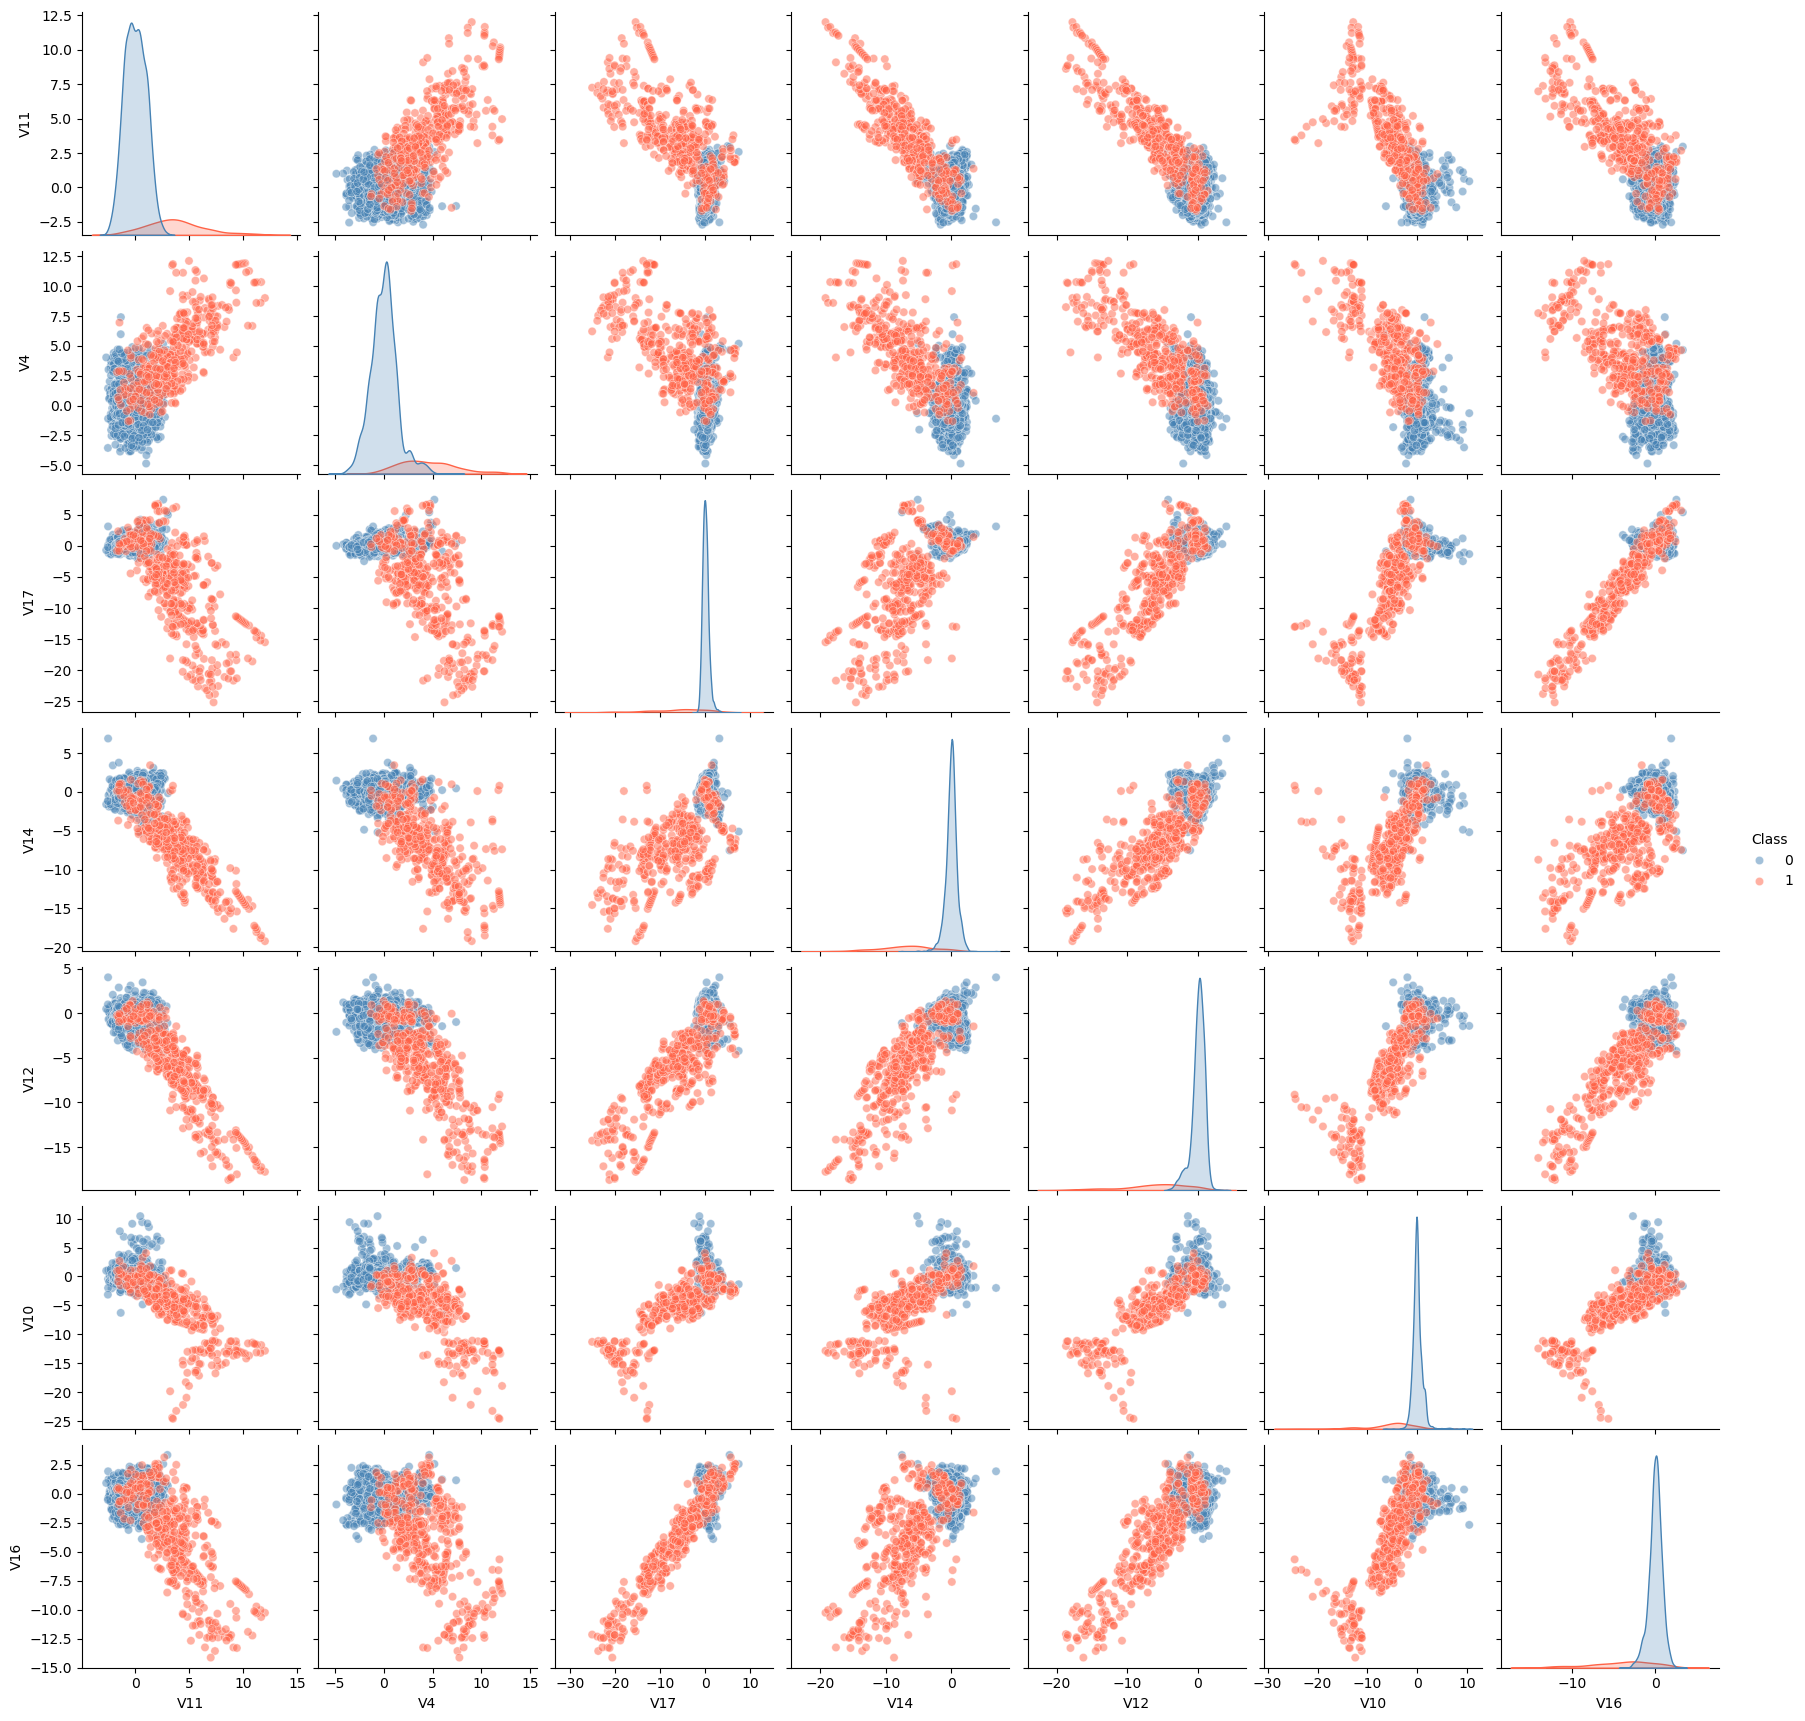

In [10]:
# ---------------------------------------------------------
# CELL 9: PAIRWISE CONTOUR & DISTRIBUTION MATRIX
# ---------------------------------------------------------
# Warning: Plotting 7x7 takes a moment. We use our tool to subsample safely.
dags.plot_pairwise_distributions(df_clean, features=my_features, target_col='Class')

Generating Modern DAG: 'Fraud Status' -> ['V17', 'V14', 'V12', 'V10', 'V16']


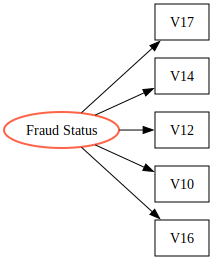

In [11]:
# ---------------------------------------------------------
# CELL 10: THE CAUSAL BLUEPRINT (DAG)
# ---------------------------------------------------------
from bayes_tools import dags

# The 'Parent' cause
my_cause = "Fraud Status"

# The 'Children' we chose based on the best 'neighborhood' separation
# We'll use the 5 strongest negative correlations for this first DAG
my_witnesses = ['V17', 'V14', 'V12', 'V10', 'V16']

# Draw it
dags.visualize_causal_graph(cause_node=my_cause, effect_nodes=my_witnesses)

In [12]:
# ---------------------------------------------------------
# CELL 11: CREATING A BALANCED DATASET FOR SAMPLING
# ---------------------------------------------------------

# 1. Isolate the frauds (The minority)
df_frauds = df_clean[df_clean['Class'] == 1]

# 2. Grab an equal amount of random normal transactions
df_normals = df_clean[df_clean['Class'] == 0].sample(n=len(df_frauds), random_state=42)

# 3. Combine them into our "Model Training Set"
df_bayes = pd.concat([df_frauds, df_normals]).sample(frac=1).reset_index(drop=True)

print(f"Sampling Set Created: {df_bayes.shape[0]} rows.")
print(f"Ratio: {df_bayes['Class'].value_counts(normalize=True)[1]*100:.1f}% Fraud")

Sampling Set Created: 946 rows.
Ratio: 50.0% Fraud


In [13]:
# ---------------------------------------------------------
# CELL 13: LOCKING IN THE 7 STAR WITNESSES
# ---------------------------------------------------------
final_features = ['V17', 'V14', 'V12', 'V10', 'V16', 'V11', 'V4']

# Prepare our data for the model
# X = the clues, y = the answer (Fraud or not)
X = df_bayes[final_features]
y = df_bayes['Class']

print(f"Ready to model with {len(final_features)} features.")
X.head()

Ready to model with 7 features.


,V17,V14,V12,V10,V16,V11,V4
0,-0.622633,-0.508418,0.699770,-0.547341,0.196977,-1.117328,0.719541
1,0.038641,1.368907,-3.884810,-0.644306,2.036461,0.843575,-2.025219
2,-4.815863,-1.808103,-3.259702,-1.445375,-2.986920,2.113900,6.249462
3,-6.465409,-8.552023,-8.752770,-4.723092,-4.534030,4.921657,2.434181
4,0.120608,1.027584,-0.868686,0.324239,0.256216,-1.273935,2.891388


In [17]:
import os
# REMOVE: os.environ["PYTENSOR_FLAGS"] = "cxx=" 
# ADD THIS INSTEAD: This helps PyTensor find your new Conda compiler
os.environ["PYTENSOR_FLAGS"] = "cxx_binary=" + os.path.join(os.environ["CONDA_PREFIX"], "bin", "clang++")

In [19]:
# ---------------------------------------------------------
# CELL 14 (FIXED): ASSEMBLING THE SKEPTICAL PYMC MODEL
# ---------------------------------------------------------
# ---------------------------------------------------------
# CELL 14 (REVISED): BACK TO 5 STAR WITNESSES
# ---------------------------------------------------------
from bayes_tools import models
import numpy as np

# We'll use just the 5 negative correlators for maximum speed/stability
limited_features = ['V17', 'V14', 'V12', 'V10', 'V16']

X_5 = df_bayes[limited_features]
y_5 = df_bayes['Class']

# Add a tiny bit of 'lubrication' noise to the math
X_jitter = X_5 + np.random.normal(0, 0.01, X_5.shape)

# Build with a VERY tight prior (sigma=0.1) to keep the walkers from falling off cliffs
fraud_model_5 = models.build_logistic_model(X_jitter, y_5, prior_sigma=0.1)

print("\nModel with 5 features and Skeptical Priors is ready.")

print("\nSkeptical Model compiled. This terrain will be much easier to walk.")

Building PyMC Logistic Model with 5 features...
Model architecture compiled successfully.

Model with 5 features and Skeptical Priors is ready.

Skeptical Model compiled. This terrain will be much easier to walk.


In [20]:
# ---------------------------------------------------------
# CELL 15 (REVISED): THE SPEED-CHECK SAMPLE
# ---------------------------------------------------------
# We use 500 draws/tune and only 2 chains to see if it's actually fast.
trace_5 = models.sample_model(fraud_model_5, draws=500, tune=500, chains=2)

Initializing NUTS using jitter+adapt_diag...


Starting MCMC Sampling: 2 chains, 500 tune, 500 draws...


Multiprocess sampling (2 chains in 2 jobs)
NUTS: [alpha, betas]


Output()

/Users/aryan/miniconda3/envs/math509/lib/python3.12/site-packages/pytensor/scalar/basic.py:2094: RuntimeWarning: invalid value encountered in divide
  return x / y
/Users/aryan/miniconda3/envs/math509/lib/python3.12/site-packages/pytensor/scalar/basic.py:2094: RuntimeWarning: invalid value encountered in divide
  return x / y


Sampling 2 chains for 500 tune and 500 draw iterations (1_000 + 1_000 draws total) took 191 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


Generating MCMC Convergence Summary...
Health Check: 'r_hat' should be strictly < 1.01. 'ess_bulk' should be > 400.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,-0.876,0.073,-0.997,-0.728,0.002,0.002,1341.0,876.0,1.0
betas[0],-0.021,0.052,-0.112,0.081,0.001,0.002,1306.0,741.0,1.0
betas[1],-0.435,0.055,-0.541,-0.338,0.002,0.002,1239.0,909.0,1.0
betas[2],-0.299,0.062,-0.418,-0.180,0.002,0.002,1306.0,711.0,1.0
betas[3],-0.187,0.060,-0.302,-0.078,0.002,0.002,1224.0,806.0,1.0
betas[4],-0.061,0.066,-0.193,0.052,0.002,0.002,1552.0,725.0,1.0


Plotting MCMC Trace and Posterior Densities...


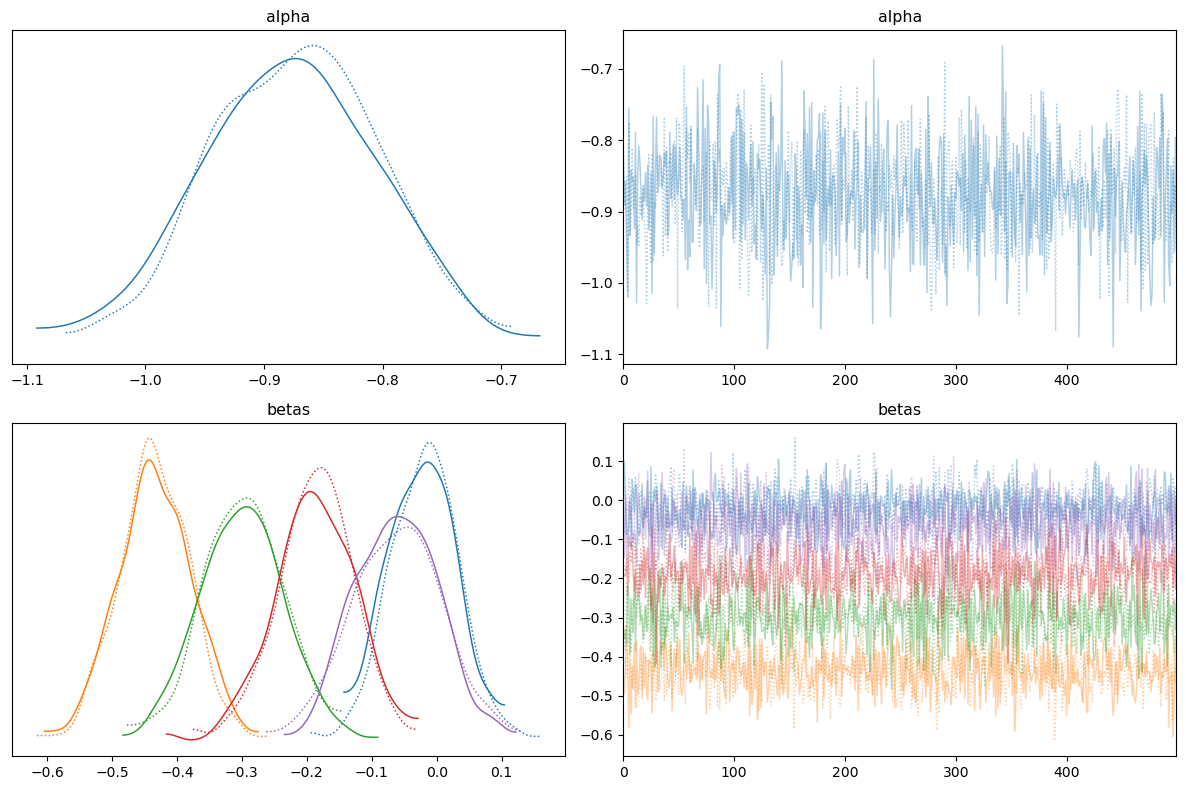

In [22]:
# ---------------------------------------------------------
# CELL 16: THE HEALTH REPORT (DIAGNOSTICS)
# ---------------------------------------------------------
from bayes_tools import diagnostics

# 1. Look at the numbers
summary = diagnostics.print_summary(trace_5)
display(summary)

# 2. Look at the 'Caterpillar' plots
# If the lines on the right look like fuzzy caterpillars, the model is healthy!
diagnostics.plot_mcmc_health(trace_5)

Sampling: [y_obs]


Output()

Generating Synthetic Data via Posterior Predictive Check (PPC)...


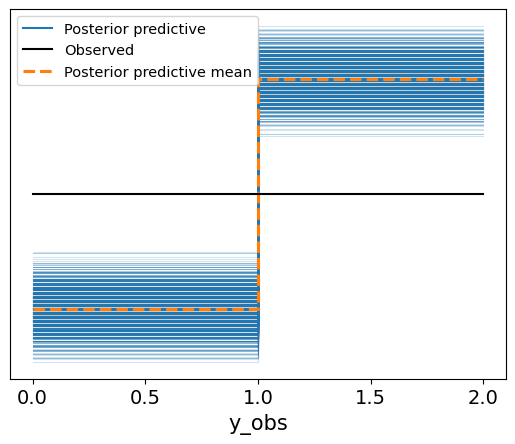

In [23]:
# ---------------------------------------------------------
# CELL 17: POSTERIOR PREDICTIVE CHECK (PPC)
# ---------------------------------------------------------
from bayes_tools import inference

# Ask the model to 'dream up' data based on the trace
ppc_data = inference.run_posterior_predictive(fraud_model_5, trace_5)

# This will show if the 'Predicted' fraud matches the 'Actual' fraud
import arviz as az
az.plot_ppc(ppc_data, kind='kde')
plt.show()

Running Decision Theory Analysis (Cost FP: 1.0, Cost FN: 10.0)...


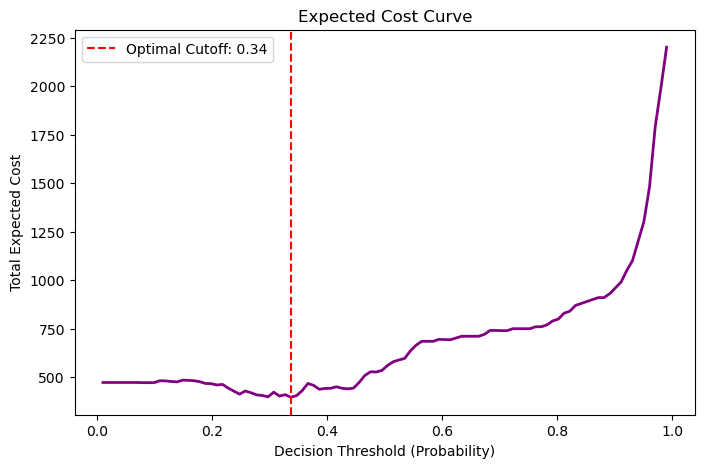

Optimal Threshold Found: 0.337


In [24]:
# ---------------------------------------------------------
# CELL 18: BAYESIAN DECISION THEORY (THE MAGIC THRESHOLD)
# ---------------------------------------------------------
from bayes_tools import inference
from scipy.special import expit # This is just the math function to calculate probabilities
import arviz as az
import numpy as np

# 1. Extract the "Best Guesses" (Means) from the trace we just generated
summary = az.summary(trace_5)
alpha_mean = summary.loc['alpha', 'mean']
beta_means = summary.loc[summary.index.str.startswith('betas'), 'mean'].values

# 2. Calculate the actual continuous probability for every row in our dataset
# This applies the learned weights to the 5 features
z_scores = alpha_mean + np.dot(X_5, beta_means)
predicted_probabilities = expit(z_scores)

# 3. Run the Cost Simulation!
# We assume letting a fraudster slip by (Cost FN) is 10x worse than annoying a customer (Cost FP)
optimal_thresh = inference.calculate_optimal_threshold(
    probabilities=predicted_probabilities, 
    y_true=y_5.values, 
    cost_fp=1.0, 
    cost_fn=10.0
)

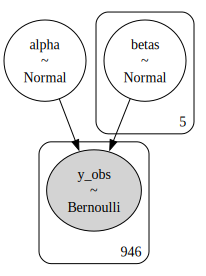

In [25]:
# ---------------------------------------------------------
# CELL 19: THE BUILT-IN PYMC DAG
# ---------------------------------------------------------
import pymc as pm

# This automatically reads the architecture of your PyMC model and draws it!
pm.model_to_graphviz(fraud_model_5)